In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
import json

data_dir = Path("/home/bjoern/Projects/Masterarbeit/simdata/server/baseline")

filename_pattern = re.compile(
    r"base(\d+)agent(\d+)_(\d+)-(\d+)#(\d+)"
)

rows = []

for file in data_dir.iterdir():

    if file.suffix != ".json":
        continue

    match = filename_pattern.match(file.stem)

    if not match:
        print(f"Skipping {file.name}")
        continue

    experiment, agent, start, goal, run = map(int, match.groups())

    with open(file) as f:
        data = json.load(f)

    info = data["info"]

    row = {
        "experiment": experiment,
        "agent": agent,
        "start": start,
        "goal": goal,
        "run": run,
        "movement": f"{start}-{goal}",
        "converged": data["trajectory"] is not None,
        "NJS": info.get("NJS"),
        "EE_NJS": info.get("Endeffector_NJS"),
        "Solution_EE_NJS": info.get("Calculated_EE_NJS"),
    }

    traj = data["trajectory"]

    if traj is not None:

        points = traj["points"]
        joints = traj["joint_names"]

        start_pos = points[0]["positions"]
        end_pos = points[-1]["positions"]
            
        for joint, s, e in zip(joints, start_pos, end_pos):
            row[f"{joint}_disp"] = e - s

        joint_vels = {j: [] for j in joints}

        for p in points:
            vels = p.get("velocities", [])

            for j, v in zip(joints, vels):
                joint_vels[j].append(v)

        # store in row
        for j in joints:
            row[f"{j}_vel"] = joint_vels[j]

    rows.append(row)


df = pd.DataFrame(rows)
print(df.head())

   experiment  agent  start  goal  run movement  converged           NJS  \
0          46      2      7     1    2      7-1       True  2.237906e+06   
1          37      2      7     9    1      7-9       True  4.941267e+06   
2          13      1      3     6    2      3-6       True  1.698831e+07   
3          39      2      7     1    2      7-1       True  1.858398e+06   
4          38      2      5     8    2      5-8       True  6.086095e+07   

       EE_NJS  Solution_EE_NJS  ...  \
0  106.194105     7.976313e+05  ...   
1   86.883654     9.339403e+05  ...   
2  161.275011     5.978836e+05  ...   
3  119.390008     6.931798e+05  ...   
4  421.636214     1.649996e+06  ...   

                               columna_rot_joint_vel  \
0  [0.0, -0.007562722275409578, 0.023045394079529...   
1  [0.0, -0.004681054910377416, 0.026128883532320...   
2  [0.0, 0.2471121667082297, 0.17434429540466106,...   
3  [0.0, -0.005344735584547386, 0.025320550145453...   
4  [0.0, -0.1161030370909975

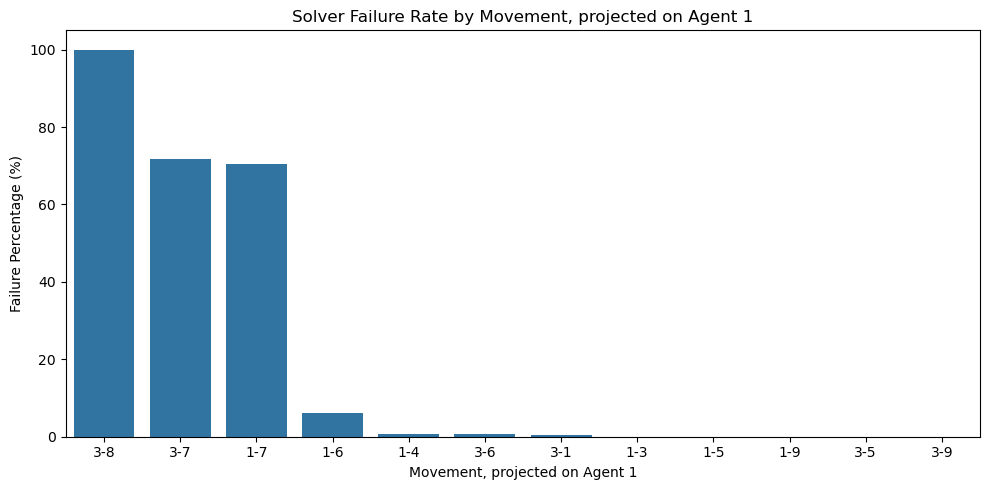

In [20]:
df["failure"] = ~df["converged"]

mirror = {
    1:5,
    2:6,
    3:7,
    4:8,
    5:1,
    6:2, 
    7:3,
    8:4,
    9:9,
}

def mirror_movement(start, goal):
    s = mirror[start]
    g = mirror[goal]
    return f"{s}-{g}"


df["projected_movement"] = np.where(
    df["agent"] == 1,
    df["movement"],
    df.apply(
        lambda r: mirror_movement(r["start"], r["goal"]),
        axis=1
    )
)

failure_rates = (
    df.groupby("projected_movement")["failure"]
      .mean()
      .mul(100)
      .reset_index(name="failure_percent")
      .sort_values("failure_percent", ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=failure_rates,
    x="projected_movement",
    y="failure_percent"
)

plt.ylabel("Failure Percentage (%)")
plt.xlabel("Movement, projected on Agent 1")
plt.title("Solver Failure Rate by Movement, projected on Agent 1")

plt.tight_layout()
plt.show()

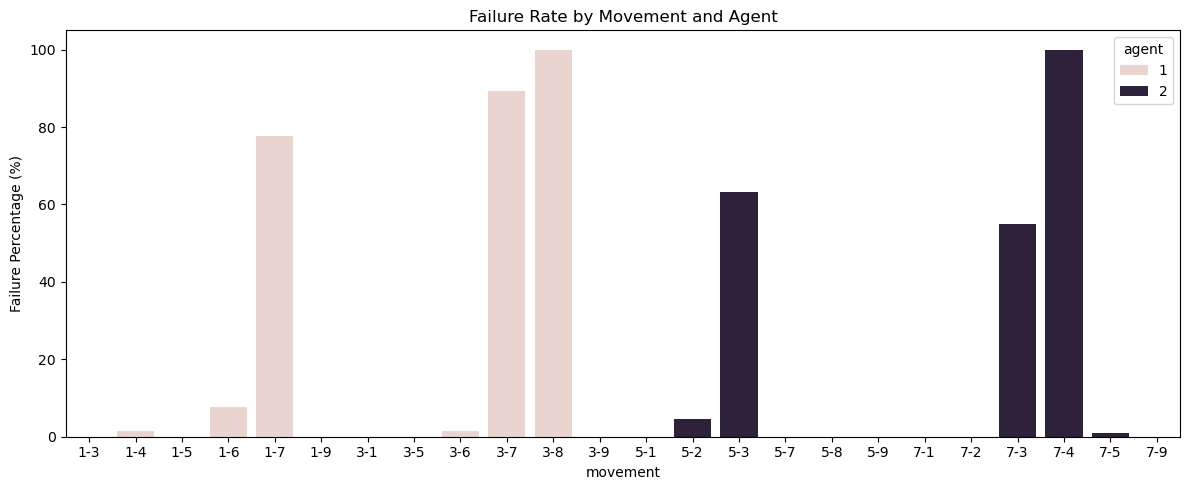

In [21]:
failure_rates = (
    df.groupby(["movement", "agent"])["failure"]
      .mean()
      .mul(100)
      .reset_index(name="failure_percent")
)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=failure_rates,
    x="movement",
    y="failure_percent",
    hue="agent"
)

plt.ylabel("Failure Percentage (%)")
plt.title("Failure Rate by Movement and Agent")

plt.tight_layout()
plt.show()

In [22]:
print(df["agent"].value_counts())
print(df["agent"].value_counts())
print(df.groupby("agent")["movement"].unique())

agent
1    861
2    860
Name: count, dtype: int64
agent
1    861
2    860
Name: count, dtype: int64
agent
1    [3-6, 3-7, 3-5, 3-1, 1-3, 3-8, 1-6, 1-9, 3-9, ...
2    [7-1, 7-9, 5-8, 5-7, 7-5, 7-3, 7-2, 5-3, 5-2, ...
Name: movement, dtype: object


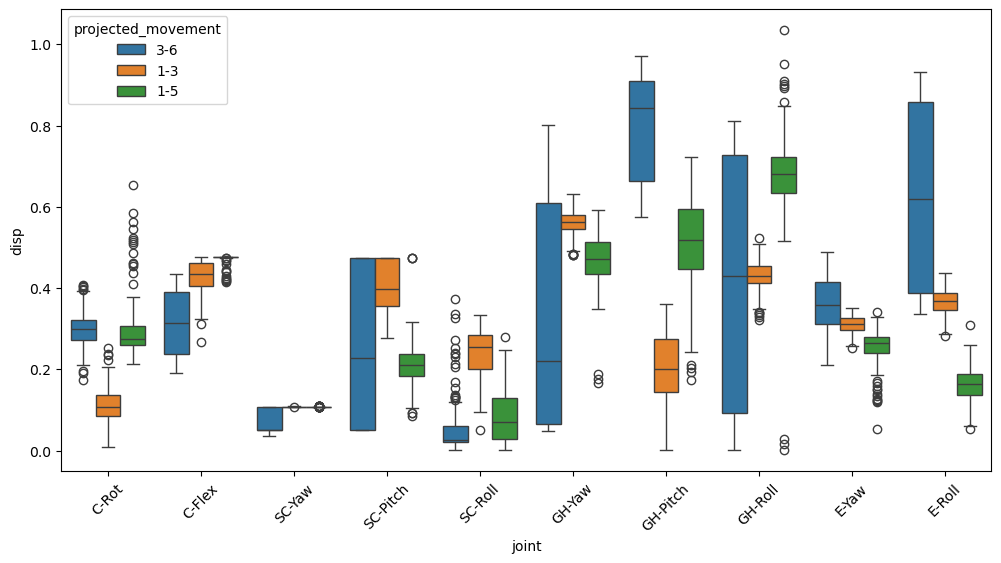

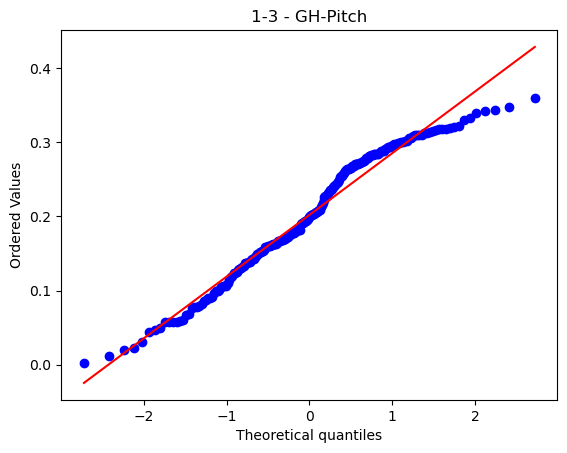

shapiro:  ShapiroResult(statistic=0.9687417149543762, pvalue=0.00011169775825692341)


In [23]:
joint_order = [
    "columna_rot_joint",
    "columna_flex_joint",
    "sternoclavicular_yaw_joint",
    "sternoclavicular_pitch_joint",
    "sternoclavicular_roll_joint",
    "glenohumeral_yaw_joint",
    "glenohumeral_pitch_joint",
    "glenohumeral_roll_joint",
    "elbow_yaw_joint",
    "elbow_roll_joint",
]

movements = ["1-3", "1-5", "3-6" ] #, "3-1"]

rows = []

for _, row in df[df["converged"]].iterrows():

    if row["projected_movement"] not in movements:
        continue

    for j in joint_order:
        rows.append({
            "projected_movement": row["projected_movement"],
            "joint": j,
            "disp": abs(row[f"{j}_disp"])
        })

long_df = pd.DataFrame(rows)

joint_stats = long_df.groupby(["projected_movement", "joint"]).agg(
    mean=("disp", "mean"),
    std=("disp", "std")
).reset_index()

joint_labels = {
    "columna_rot_joint": "C-Rot",
    "columna_flex_joint": "C-Flex",
    "sternoclavicular_yaw_joint": "SC-Yaw",
    "sternoclavicular_pitch_joint": "SC-Pitch",
    "sternoclavicular_roll_joint": "SC-Roll",
    "glenohumeral_yaw_joint": "GH-Yaw",
    "glenohumeral_pitch_joint": "GH-Pitch",
    "glenohumeral_roll_joint": "GH-Roll",
    "elbow_yaw_joint": "E-Yaw",
    "elbow_roll_joint": "E-Roll",
}

joint_stats["joint"] = joint_stats["joint"].map(joint_labels)
long_df["joint"] = long_df["joint"].map(joint_labels)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=long_df,
    x="joint",
    y="disp",
    hue="projected_movement"
)

plt.xticks(rotation=45)
plt.show()

#Box plot?

movement = "1-3"
joint = "GH-Pitch"

x = long_df[
    (long_df.projected_movement == movement) &
    (long_df.joint == joint)
]["disp"]

from scipy.stats import probplot

probplot(x, dist="norm", plot=plt)
plt.title(f"{movement} - {joint}")
plt.show()

from scipy.stats import shapiro

print("shapiro: ", shapiro(x))

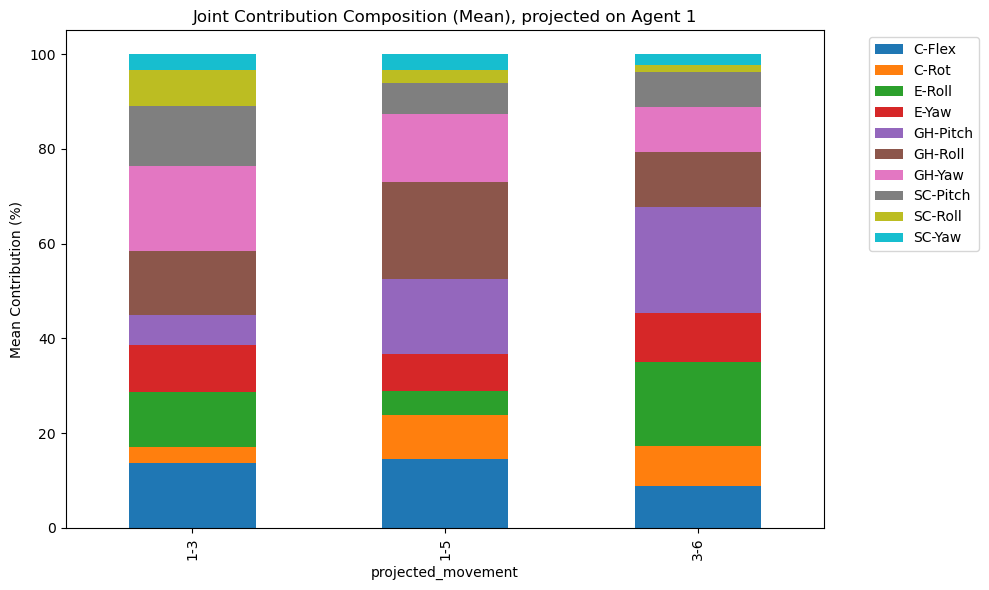

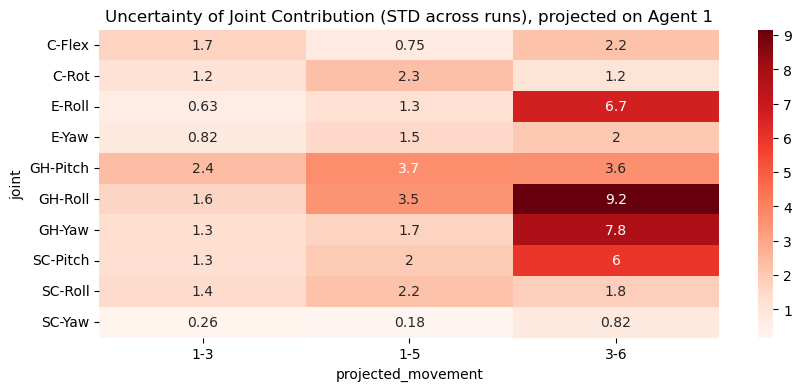

In [24]:
rows = []

for _, row in df[df["converged"]].iterrows():

    if row["projected_movement"] not in movements:
        continue

    disp = np.array([abs(row[f"{j}_disp"]) for j in joint_order])
    total = disp.sum()

    if total == 0:
        continue

    contrib = disp / total

    for j, c in zip(joint_order, contrib):

        rows.append({
            "projected_movement": row["projected_movement"],
            "joint": j,
            "contribution": c * 100
        })

long_df = pd.DataFrame(rows)

joint_stats = long_df.groupby(["projected_movement", "joint"]).agg(
    mean=("contribution", "mean"),
    std=("contribution", "std")
).reset_index()

joint_stats["joint"] = joint_stats["joint"].map(joint_labels)

pivot = joint_stats.pivot(
    index="projected_movement",
    columns="joint",
    values="mean"
)

ax = pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.ylabel("Mean Contribution (%)")
plt.title("Joint Contribution Composition (Mean), projected on Agent 1")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

err = joint_stats.pivot(
    columns="projected_movement",
    index="joint",
    values="std"
)

plt.figure(figsize=(10,4))

sns.heatmap(
    err,
    annot=True,
    cmap="Reds"
)

plt.title("Uncertainty of Joint Contribution (STD across runs), projected on Agent 1")
plt.show()

<Figure size 1200x600 with 0 Axes>

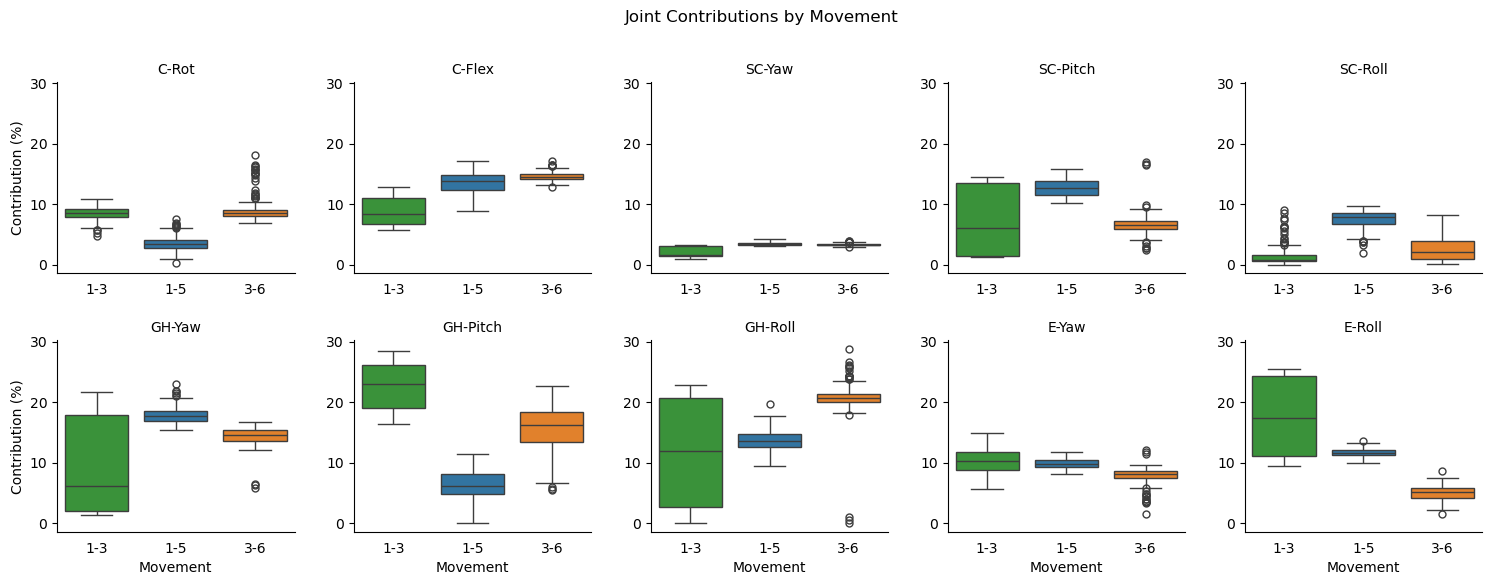

In [25]:
rows = []

for _, row in df[df["converged"]].iterrows():

    if row["projected_movement"] not in movements:
        continue

    disp = np.array([abs(row[f"{j}_disp"]) for j in joint_order])
    total = disp.sum()

    if total == 0:
        continue

    contrib = disp / total

    for j, c in zip(joint_order, contrib):

        rows.append({
            "projected_movement": row["projected_movement"],
            "joint": j,
            "contribution": c * 100
        })

long_df = pd.DataFrame(rows)

# map joint names for plotting
long_df["joint"] = long_df["joint"].map(joint_labels)

plt.figure(figsize=(12, 6))

palette = {
    "1-3": "#1f77b4",
    "1-5": "#ff7f0e",
    "3-6": "#2ca02c"
}
g = sns.catplot(
    data=long_df,
    x="projected_movement",
    y="contribution",
    col="joint",
    col_wrap=5,
    kind="box",
    hue="projected_movement",
    palette=palette,
    sharey=True,
    height=3,
    dodge=False,
    sharex=False
)

g.fig.subplots_adjust( 
    left=0.03, 
    right=0.98, 
    top=0.90, 
    bottom=0.15, 
    wspace=0.25, 
    hspace=0.35
)


g.set_xticklabels( movements, rotation=0,)
g.tick_params(bottom=False)
g.set_titles("{col_name}")
g.set_axis_labels("Movement", "Contribution (%)")
g.fig.suptitle("Joint Contributions by Movement", y=1.02)

for ax in g.axes.flat:
    ax.set_xlim(-0.5, 2.5)
    ax.margins(x=0.0)

for ax in g.axes.flat:
    ax.tick_params(axis="y", labelleft=True)

plt.show()

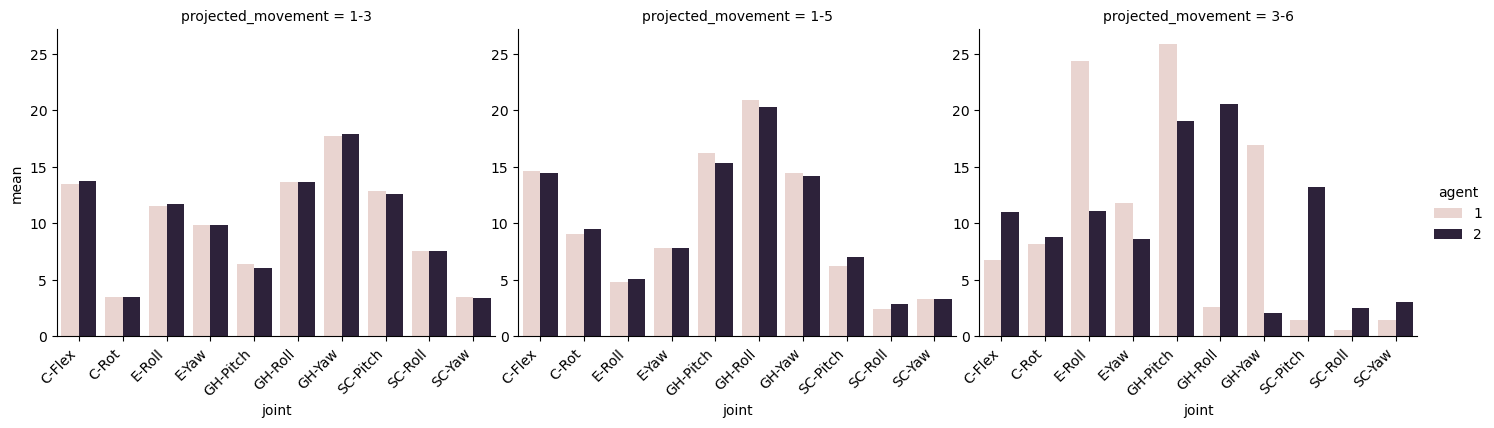

In [26]:
rows = []

for _, row in df[df["converged"]].iterrows():

    if row["projected_movement"] not in movements:
        continue

    disp = np.array([abs(row[f"{j}_disp"]) for j in joint_order])
    total = disp.sum()

    if total == 0:
        continue

    contrib = disp / total

    for j, c in zip(joint_order, contrib):
        rows.append({
            "projected_movement": row["projected_movement"],
            "agent": row["agent"],
            "joint": j,
            "contribution": c * 100
        })

long_df = pd.DataFrame(rows)

joint_stats = (
    long_df
    .groupby(["projected_movement", "agent", "joint"])
    .agg(
        mean=("contribution", "mean"),
        std=("contribution", "std")
    )
    .reset_index()
)

joint_stats["joint"] = joint_stats["joint"].map(joint_labels)


g = sns.catplot(
    data=joint_stats,
    kind="bar",
    x="joint",
    y="mean",
    hue="agent",
    col="projected_movement",
    col_wrap=3,
    height=4,
    aspect=1.2,
    errorbar=None,
    sharey=True
)

g.fig.subplots_adjust(hspace=0.3)

for ax in g.axes.flat:
    ax.tick_params(labelbottom=True)
    
for ax in g.axes.flat:
    ax.tick_params(axis="y", labelleft=True)

for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(),
             rotation=45,
             ha="right")
    


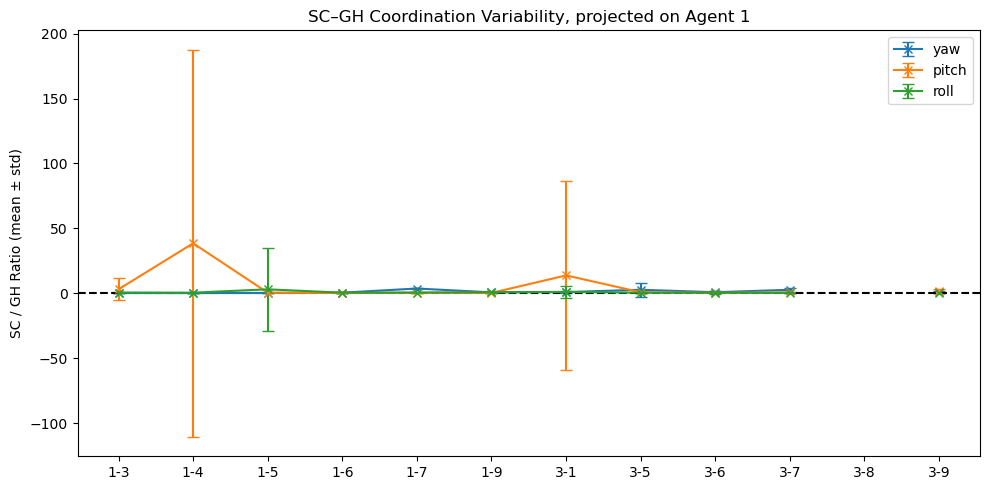

In [27]:
sc_gh_pairs = [
    ("yaw",   "sternoclavicular_yaw_joint",   "glenohumeral_yaw_joint"),
    ("pitch", "sternoclavicular_pitch_joint", "glenohumeral_pitch_joint"),
    ("roll",  "sternoclavicular_roll_joint",  "glenohumeral_roll_joint"),
]

rows = []

for movement in sorted(df["projected_movement"].unique()):

    subset = df[
        (df["projected_movement"] == movement) &
        (df["converged"])
    ]

    for axis, sc, gh in sc_gh_pairs:

        sc_vals = subset[f"{sc}_disp"].abs()
        gh_vals = subset[f"{gh}_disp"].abs()

        ratio = sc_vals / gh_vals.replace(0, np.nan)
        #ratio = np.log((sc_vals + 1e-8) / (gh_vals + 1e-8))

        rows.append({
            "projected_movement": movement,
            "axis": axis,
            "mean": ratio.mean(),
            "std": ratio.std() 
        })

joint_stats = pd.DataFrame(rows)

plt.figure(figsize=(10,5))

for axis in joint_stats["axis"].unique():

    sub = joint_stats[joint_stats["axis"] == axis]

    plt.errorbar(
        sub["projected_movement"],
        sub["mean"],
        yerr= sub["std"],
        label=axis,
        capsize=4,
        marker="x"
    )

plt.axhline(0.5, linestyle="--", color="black")

plt.ylabel("SC / GH Ratio (mean ± std)")
plt.title("SC–GH Coordination Variability, projected on Agent 1")

#plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()


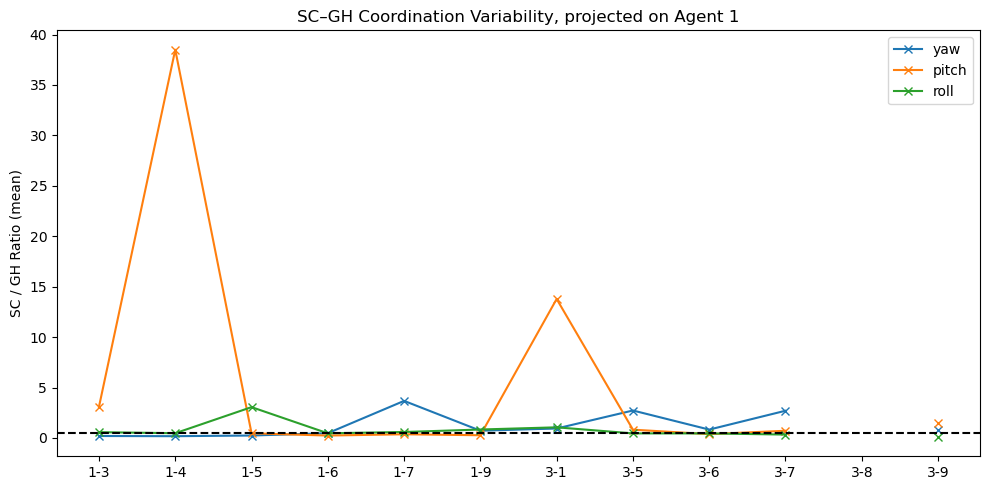

In [28]:
# same shit as before but without error bars:
plt.figure(figsize=(10,5))

# enforce consistent order
movement_order = sorted(joint_stats["projected_movement"].unique())

for axis in joint_stats["axis"].unique():

    sub = joint_stats[joint_stats["axis"] == axis]

    # force alignment with movement order
    sub = sub.set_index("projected_movement").reindex(movement_order).reset_index()

    plt.plot(
        sub["projected_movement"],
        sub["mean"],
        label=axis,
        marker="x"
    )

plt.axhline(0.5, linestyle="--", color="black")

plt.ylabel("SC / GH Ratio (mean)")
plt.title("SC–GH Coordination Variability, projected on Agent 1")

plt.legend()
plt.tight_layout()
plt.show()
#box plot, outlier raus 

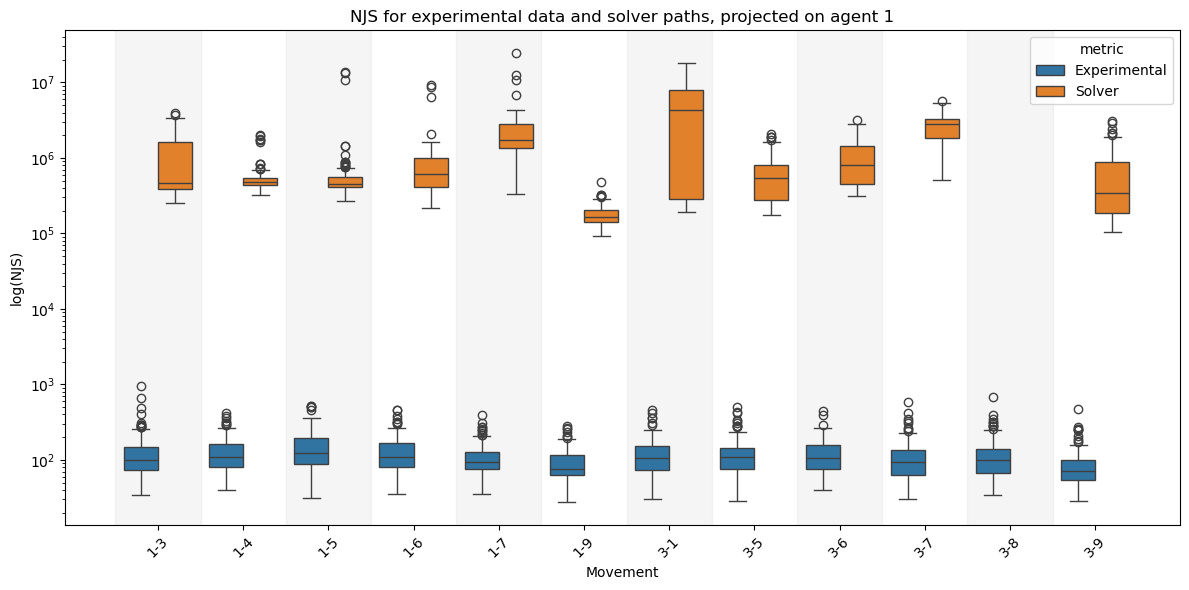

In [29]:
rows = []

for movement, group in df.groupby("projected_movement"):

    # EE_NJS (all runs)
    for v in group["EE_NJS"].dropna():
        rows.append({
            "projected_movement": movement,
            "metric": "EE_NJS",
            "value": v
        })

    # NJS (only converged)
    converged = group[group["converged"]]
    for v in converged["Solution_EE_NJS"].dropna():
        rows.append({
            "projected_movement": movement,
            "metric": "Solution_EE_NJS",
            "value": v
        })

metric_labels = {
    "EE_NJS": "Experimental",
    "Solution_EE_NJS": "Solver"
}


long_df = pd.DataFrame(rows)
long_df["metric"] = long_df["metric"].map(metric_labels)

plt.figure(figsize=(12, 6))

ax = sns.boxplot(
    data=long_df,
    x="projected_movement",
    y="value",
    hue="metric",
    showfliers=True
)

ax.set_yscale("log")

x_labels = sorted(long_df["projected_movement"].unique())
for i, m in enumerate(x_labels):
    if i % 2 == 0:
        ax.axvspan(i - 0.5, i + 0.5, color="gray", alpha=0.08)

plt.ylabel("log(NJS)")
plt.xlabel("Movement")
plt.xticks(rotation=45)
plt.title("NJS for experimental data and solver paths, projected on agent 1")

plt.tight_layout()
plt.show()


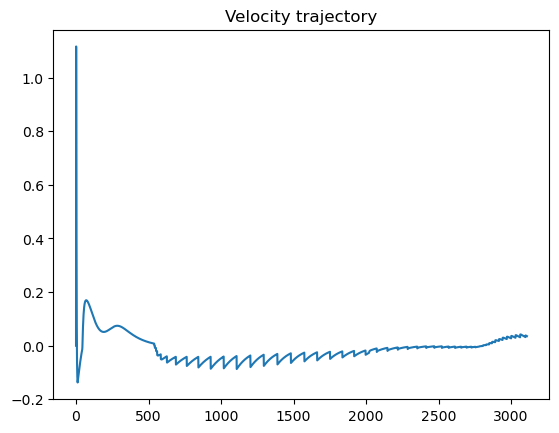

In [30]:

row = df.iloc[0]

plt.plot(row["elbow_yaw_joint_vel"])
plt.title("Velocity trajectory")
plt.show()

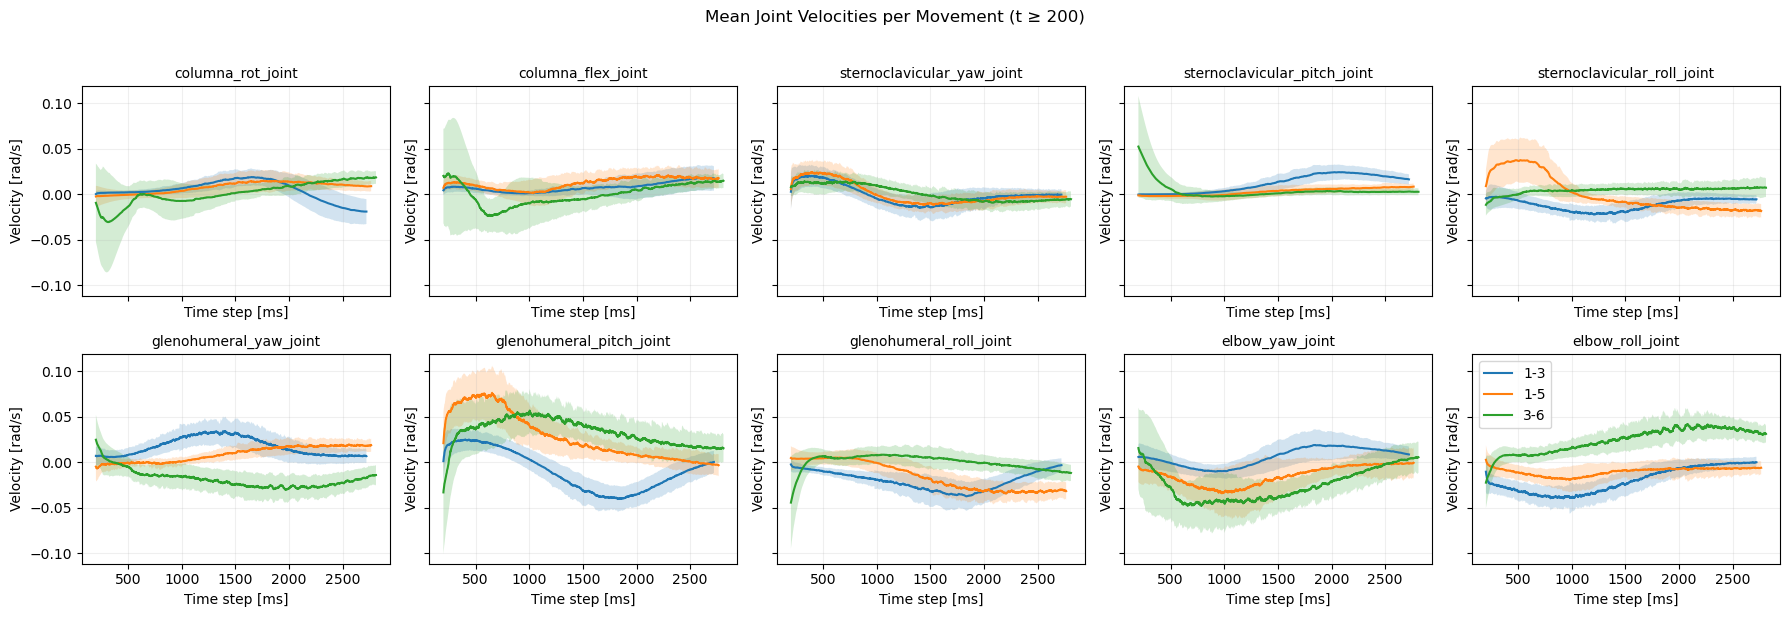

In [40]:
joint_list = joint_order

fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(18, 6),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

start_idx = 200  # 👈 add this

for ax, joint in zip(axes, joint_list):

    vel_key = f"{joint}_vel"

    for movement in movements:

        subset = df[
            (df["converged"]) &
            (df["projected_movement"] == movement)
        ]

        trajectories = []

        for _, row in subset.iterrows():

            vel = row.get(vel_key, None)
            if vel is None:
                continue

            trajectories.append(vel)

        if len(trajectories) == 0:
            continue

        # align lengths (still OK, but we will slice AFTER)
        min_len = min(len(v) for v in trajectories)
        aligned = np.array([v[:min_len] for v in trajectories])

        # compute stats
        mean_traj = aligned.mean(axis=0)
        std_traj = aligned.std(axis=0)

        # 👉 slice here
        mean_traj = mean_traj[start_idx:]
        std_traj = std_traj[start_idx:]
        t = np.arange(start_idx, start_idx + len(mean_traj))

        ax.plot(t, mean_traj, label=movement)

        ax.fill_between(
            t,
            mean_traj - std_traj,
            mean_traj + std_traj,
            alpha=0.2
        )

    ax.set_title(joint, fontsize=10)
    ax.set_xlabel("Time step [ms]")
    ax.set_ylabel("Velocity [rad/s]")
    ax.grid(True, alpha=0.2)

# remove empty axes
for i in range(len(joint_list), len(axes)):
    fig.delaxes(axes[i])

fig.suptitle("Mean Joint Velocities per Movement (t ≥ 200)", y=1.02)
plt.tight_layout()
plt.legend()
plt.show()